# Photonic QGAN with `PhotonicGenerator`

This notebook demonstrates a compact Adam-trained photonic QGAN workflow using MerLin's `PhotonicGenerator`. It follows the structure of the photonic QGAN model at documentation scale: repeated quantum generator heads produce image patches, `ImageAdapter` assembles them into images, and a classical discriminator trains against Optdigits samples.

![Photonic QGAN overview](../../_static/reproduced_papers/photonicQGAN.png)

The run below is intentionally short and self-contained. Increase `training_iterations` for longer experiments.

In [13]:
from __future__ import annotations

import copy
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.datasets import load_digits
from torch import nn

import merlin as ML

## Configuration

The demo uses four patch heads, one latent feature, an 8 by 8 digit target, and one discriminator update followed by three generator updates.

In [14]:
seed = 0
digit = 0
training_iterations = 600
batch_size = 4
image_size = 8
latent_dim = 1
generator_heads = 4

input_state = (0, 1, 0, 1, 0)

lr_d = 0.0002
lr_g = 0.004
adam_betas = (0.5, 0.99)
d_steps = 1
g_steps = 3

random.seed(seed)
np.random.seed(seed)
_ = torch.manual_seed(seed)

## Load Optdigits samples

The notebook uses `sklearn.datasets.load_digits`, so it can run without a separate data checkout. Pixel values are normalized to `[0, 1]`.

In [15]:
digits = load_digits()
mask = digits.target == digit
real_images = torch.tensor(digits.images[mask], dtype=torch.float32).unsqueeze(1) / 16.0
real_vectors = real_images.reshape(real_images.shape[0], -1)

sample_generator = torch.Generator().manual_seed(seed + 17)
batch_indices = torch.randint(
    real_vectors.shape[0],
    (training_iterations, batch_size),
    generator=sample_generator,
)
real_batches = [real_vectors[indices] for indices in batch_indices]
real_preview = real_images[batch_indices[0]]

print(f"digit samples: {real_vectors.shape[0]}")
print(f"training batches: {len(real_batches)}")

digit samples: 178
training batches: 600


## Build the MerLin photonic generator

`count=4` creates four independent heads with the same circuit structure. Each head returns Fock-space probabilities with binary occupancy readout, then the image adapter maps each head to one patch of the generated image.

In [ ]:
### Paper circuit bricks


import perceval as pcvl
def var_circuit(n_modes:int,param_start_index:int=0)->pcvl.Circuit:
    trainable_params=[pcvl.Parameter(f"phi{i+param_start_index}") for i in (2*n_modes)-1]
    circ=pcvl.Circuit(m=n_modes)
    for i in range(n_modes):
        circ.add([i],component=pcvl.PS(trainable_params[i]))
    for i,j in enumerate(range(start=0,stop=n_modes-1,step=2)):
        circ.add([j,j+1],component=pcvl.BS(trainable_params[i+n_modes]))
    for i,j in enumerate(range(start=1,stop=n_modes-1,step=2)):
        circ.add([j,j+1],component=pcvl.BS(trainable_params[i+n_modes+(n_modes//2)]))
    
    return circ

def encoding_circuit(n_modes:int,mode_to_target:int,param_index:int=0)->pcvl.Circuit:
    encoding_param=pcvl.Parameter(f"theta{param_index}")
    circ=pcvl.Circuit(m=n_modes)
    circ.add([mode_to_target],component=pcvl.PS(encoding_param))

    return circ

In [ ]:
def make_generator_head() -> ML.QuantumLayer:
    builder = ML.CircuitBuilder(n_modes=len(input_state))
    builder.add_entangling_layer(trainable=True, name="var_0")
    builder.add_angle_encoding(modes=[2], name="enc")
    builder.add_entangling_layer(trainable=True, name="var_1")

    return ML.QuantumLayer(
        input_size=latent_dim,
        builder=builder,
        input_state=input_state,
        measurement_strategy=ML.MeasurementStrategy.probs(
            computation_space=ML.ComputationSpace.FOCK,
            occupancy_readout=True,
        ),
    )





generator = ML.PhotonicGenerator(
    layers=make_generator_head(),
    count=generator_heads,
    output_adapter=ML.ImageAdapter(
        shape=(1, image_size, image_size),
        headwise=True,
        normalize_patches=True,
    ),
)

fixed_noise = torch.normal(0.0, 2 * math.pi, (batch_size, latent_dim))
with torch.no_grad():
    generated_before = generator(fixed_noise).detach()

measurements = generator.measure(fixed_noise)
print(f"heads: {len(generator)}")
print(f"trainable parameters: {sum(p.numel() for p in generator.parameters())}")
print(f"per-head output widths: {[output.shape[1] for output in measurements.outputs]}")
print(f"image batch shape: {tuple(generated_before.shape)}")

heads: 4
trainable parameters: 160
per-head output widths: [15, 15, 15, 15]
image batch shape: (4, 1, 8, 8)


## Train with Adam

The generator and discriminator are ordinary PyTorch modules. `loss.backward()` populates gradients for the MerLin quantum layers, and the user-selected Adam optimizers own the parameter updates.

In [17]:
discriminator = nn.Sequential(
    nn.Linear(image_size * image_size, 32),
    nn.LeakyReLU(0.2),
    nn.Linear(32, 16),
    nn.LeakyReLU(0.2),
    nn.Linear(16, 1),
)
criterion = nn.BCEWithLogitsLoss()
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=adam_betas)
optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=adam_betas)

noise_generator = torch.Generator().manual_seed(seed + 31)
d_losses: list[float] = []
g_losses: list[float] = []
similarity_scores: list[float] = []
best_similarity = float("-inf")
best_state = copy.deepcopy(generator.state_dict())
best_iteration = 0


def global_ssim(x: np.ndarray, y: np.ndarray) -> float:
    c1 = 0.01**2
    c2 = 0.03**2
    x = x.astype(np.float64, copy=False)
    y = y.astype(np.float64, copy=False)
    mu_x = float(x.mean())
    mu_y = float(y.mean())
    var_x = float(((x - mu_x) ** 2).mean())
    var_y = float(((y - mu_y) ** 2).mean())
    cov_xy = float(((x - mu_x) * (y - mu_y)).mean())
    numerator = (2 * mu_x * mu_y + c1) * (2 * cov_xy + c2)
    denominator = (mu_x**2 + mu_y**2 + c1) * (var_x + var_y + c2)
    return numerator / denominator


def batch_similarity(real: torch.Tensor, fake: torch.Tensor) -> float:
    real_batch = real.detach().cpu().numpy().reshape(batch_size, image_size, image_size)
    fake_batch = fake.detach().cpu().numpy().reshape(batch_size, image_size, image_size)
    total = 0.0
    for real_image in real_batch:
        for fake_image in fake_batch:
            total += global_ssim(
                np.clip(real_image, 0.0, 1.0),
                np.clip(fake_image, 0.0, 1.0),
            )
    return total / (batch_size * batch_size)


for iteration, real_data in enumerate(real_batches, start=1):
    real_labels = torch.full((batch_size,), 0.9)
    fake_labels = torch.zeros(batch_size)
    generator_labels = torch.full((batch_size,), 0.9)

    d_step_losses = []
    for _ in range(d_steps):
        noise_d = torch.normal(
            0.0,
            2 * math.pi,
            (batch_size, latent_dim),
            generator=noise_generator,
        )
        fake_for_d = generator(noise_d).reshape(batch_size, -1).detach()

        optimizer_d.zero_grad()
        d_loss = criterion(discriminator(real_data).view(-1), real_labels)
        d_loss = d_loss + criterion(discriminator(fake_for_d).view(-1), fake_labels)
        d_loss.backward()
        optimizer_d.step()
        d_step_losses.append(float(d_loss.detach()))

    for parameter in discriminator.parameters():
        parameter.requires_grad_(False)

    g_step_losses = []
    fake_for_metrics = None
    for _ in range(g_steps):
        noise_g = torch.normal(
            0.0,
            2 * math.pi,
            (batch_size, latent_dim),
            generator=noise_generator,
        )
        optimizer_g.zero_grad()
        fake_for_g = generator(noise_g).reshape(batch_size, -1)
        g_loss = criterion(discriminator(fake_for_g).view(-1), generator_labels)
        g_loss.backward()
        optimizer_g.step()
        g_step_losses.append(float(g_loss.detach()))
        fake_for_metrics = fake_for_g

    for parameter in discriminator.parameters():
        parameter.requires_grad_(True)

    if fake_for_metrics is None:
        raise RuntimeError("Generator update did not produce samples.")

    similarity = batch_similarity(real_data, fake_for_metrics)
    if similarity > best_similarity:
        best_similarity = similarity
        best_iteration = iteration
        best_state = copy.deepcopy(generator.state_dict())

    d_losses.append(float(np.mean(d_step_losses)))
    g_losses.append(float(np.mean(g_step_losses)))
    similarity_scores.append(similarity)

generator.load_state_dict(best_state)
with torch.no_grad():
    generated_best = generator(fixed_noise).detach()

has_generator_gradient = any(
    parameter.grad is not None and parameter.grad.abs().sum() > 0
    for parameter in generator.parameters()
)

print(f"training iterations: {training_iterations}")
print(f"best iteration: {best_iteration}")
print(f"best batch similarity: {best_similarity:.3f}")
print(f"generator gradients populated: {has_generator_gradient}")

training iterations: 600
best iteration: 351
best batch similarity: 0.785
generator gradients populated: True


## Results

The first row shows real digit-0 samples. The second row shows the generator before training. The third row shows the best checkpoint selected during the short Adam run.

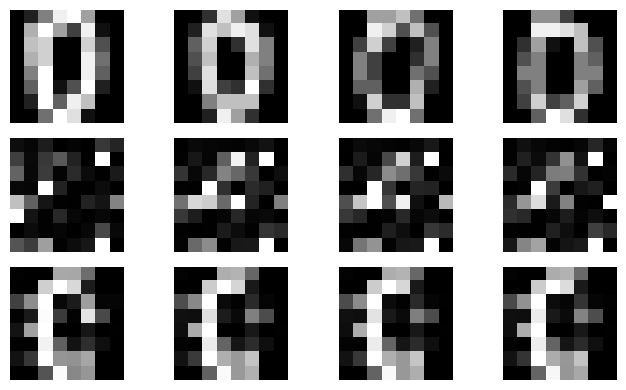

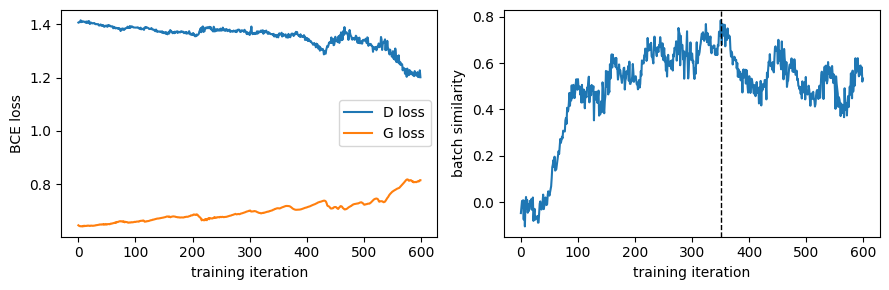

In [18]:
def show_grid(images: torch.Tensor, title: str, axes: np.ndarray) -> None:
    flat_axes = axes.reshape(-1)
    for axis, image in zip(flat_axes, images, strict=False):
        axis.imshow(image.squeeze().cpu(), cmap="gray", vmin=0.0, vmax=1.0)
        axis.axis("off")
    for axis in flat_axes[len(images):]:
        axis.axis("off")
    axes[0].set_ylabel(title, rotation=0, labelpad=35, va="center")


fig, axes = plt.subplots(3, batch_size, figsize=(7, 4))
show_grid(real_preview, "real", axes[0])
show_grid(generated_before, "before", axes[1])
show_grid(generated_best, "best", axes[2])
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(d_losses, label="D loss")
axes[0].plot(g_losses, label="G loss")
axes[0].set_xlabel("training iteration")
axes[0].set_ylabel("BCE loss")
axes[0].legend()

axes[1].plot(similarity_scores)
axes[1].axvline(best_iteration - 1, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("training iteration")
axes[1].set_ylabel("batch similarity")
fig.tight_layout()
plt.show()

## What this demonstrates

This notebook exercises the public MerLin path needed by the photonic QGAN model: repeated independent generator heads via `PhotonicGenerator(..., count=...)`, Fock-space occupancy readout, headwise image adaptation, a classical discriminator, and standard PyTorch Adam updates. The example is intentionally small; paper-scale experiments should use longer runs and checkpoint selection.